In [123]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.metrics import F1Score

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [124]:
# Changing the data labels into binary for a chosen class in the dataset. Here we have chosen frogs, and all the labels who is not a
# a frog will be 0 and vice verse if it is a frog.
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

In [125]:
from tensorflow.keras import callbacks

def make_model(metric):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 32,
            epochs = 10,
            validation_data = (x_test, y_test),
            callbacks = [early_stopping]
        )
        return history, model

In [126]:
acc_history, acc_model = make_model('accuracy')

low_th, medium_th, high_th = 0.25, 0.5, 0.75

f1_history, f1_model = make_model(F1Score(threshold=medium_th, average='micro'))

c:\Users\dhaaa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9041 - loss: 1.0278 - val_accuracy: 0.9373 - val_loss: 0.3027
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9382 - loss: 0.2318 - val_accuracy: 0.8300 - val_loss: 0.4207
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9450 - loss: 0.2120 - val_accuracy: 0.9473 - val_loss: 0.1979
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9495 - loss: 0.2011 - val_accuracy: 0.9406 - val_loss: 0.2573
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9551 - loss: 0.1815 - val_accuracy: 0.9066 - val_loss: 0.2668
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9564 - loss: 0.1769 - val_accuracy: 0.9398 - val_loss: 0.2369
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9628 - loss: 0.1659 - val_accuracy: 0.9555 - val_loss: 0.1742
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9647 -

In [151]:
from sklearn.metrics import confusion_matrix

def make_pred(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = make_pred(y_pred_acc)
acc_cf = confusion_matrix(y_test, y_pred_acc)
y_pred_f1 = f1_model.predict(x_test)
y_pred_f1 = make_pred(y_pred_f1)
f1_cf = confusion_matrix(y_test, y_pred_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Axes: >

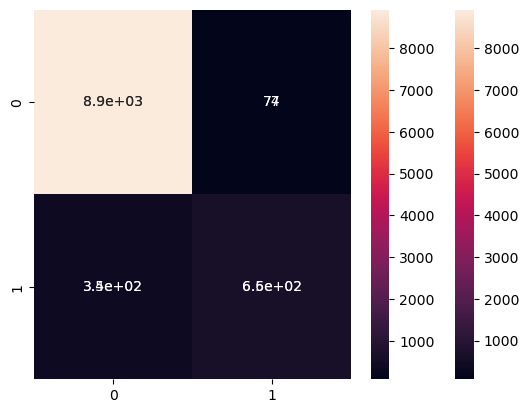

In [ ]:
import seaborn as sns

sns.heatmap(acc_cf, annot=True)
sns.heatmap(f1_cf, annot=True)

313/313 - 1s - 4ms/step - accuracy: 0.9602 - loss: 0.1656


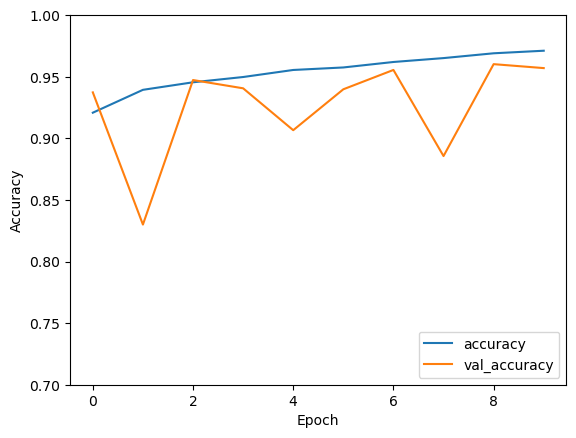

In [141]:
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.7, 1])
plt.legend(loc='lower right')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - f1_score: 0.7686 - loss: 0.1763


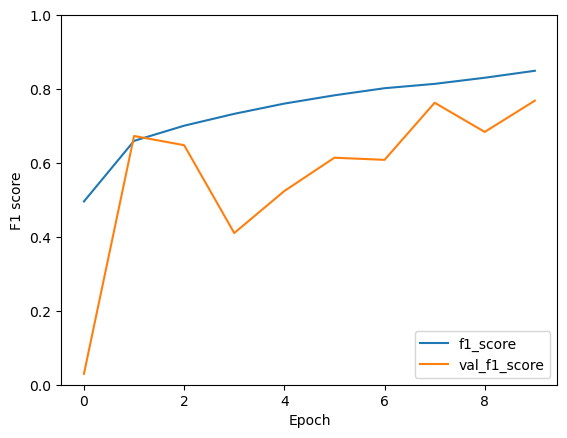

In [138]:
plt.plot(f1_history.history['f1_score'], label='f1_score')
plt.plot(f1_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = f1_model.evaluate(x_test, y_test, verbose=2)

In [139]:
img = tf.keras.utils.load_img('./media/frog.jpg', target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array = np.array(img_array) / 255.0

prediction = acc_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

prediction = f1_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0.22087857]]
not frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0.375263]]
not frog


Accuracy metric: god accuracy, ca. 0.95, lite overfitting, klarer frog med en prediction øve 0.7

F1 score: 